In [1]:
!pip install ultralytics kagglehub
from ultralytics import YOLO
import os, shutil, random, yaml, cv2, kagglehub, glob
from IPython.display import Image, display
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


/home/eurico/arquivos/caries-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("thunderpede/panoramic-dental-dataset")
path

'/home/eurico/.cache/kagglehub/datasets/thunderpede/panoramic-dental-dataset/versions/2'

In [3]:
dst = "kaggle/data"
shutil.rmtree(dst, ignore_errors=True)
shutil.copytree(str(path), dst, dirs_exist_ok=True)

shutil.rmtree(dst + "/images", ignore_errors=True)
os.rename(dst + "/images_cut", dst + "/images")

shutil.rmtree(dst + "/labels", ignore_errors=True)
os.rename(dst + "/annotations", dst + "/labels")

for item in os.listdir(dst + "/labels/bboxes_caries"):
    shutil.move(os.path.join(dst + "/labels/bboxes_caries", item), dst + "/labels")

shutil.rmtree(dst + "/labels/bboxes_caries", ignore_errors=True)
shutil.rmtree(dst + "/labels/bboxes_teeth", ignore_errors=True)

print("imagens:", len(os.listdir(dst + "/images")))
print("labels: ", len(os.listdir(dst + "/labels")))

imagens: 100
labels:  100


In [4]:
lab = dst + "/labels"
img_dir = dst + "/images"

for arq in sorted(os.listdir(lab)):
    if not arq.endswith(".txt"):
        continue
    caminho = os.path.join(lab, arq)
    stem = os.path.splitext(arq)[0]

    im = cv2.imread(os.path.join(img_dir, stem + ".png"))
    if im is None:
        continue
    h, w = im.shape[:2]

    novas = []
    for linha in open(caminho).read().split("\n"):
        p = linha.replace(",", " ").split()
        if len(p) < 4:
            continue
        x1, y1, x2, y2 = [float(v) for v in p[-4:]]
        bw, bh = abs(x2 - x1), abs(y2 - y1)
        cx, cy = min(x1, x2) + bw/2, min(y1, y2) + bh/2
        novas.append("0 %.6f %.6f %.6f %.6f" % (cx/w, cy/h, bw/w, bh/h))

    open(caminho, "w").write("\n".join(novas))

print("convertido")
print(open(os.path.join(lab, sorted(os.listdir(lab))[0])).read())

convertido
0 0.299479 0.430339 0.033854 0.087240
0 0.745768 0.440755 0.020182 0.042969
0 0.768555 0.440104 0.005859 0.010417
0 0.526367 0.498698 0.009766 0.044271
0 0.512370 0.505859 0.005208 0.022135


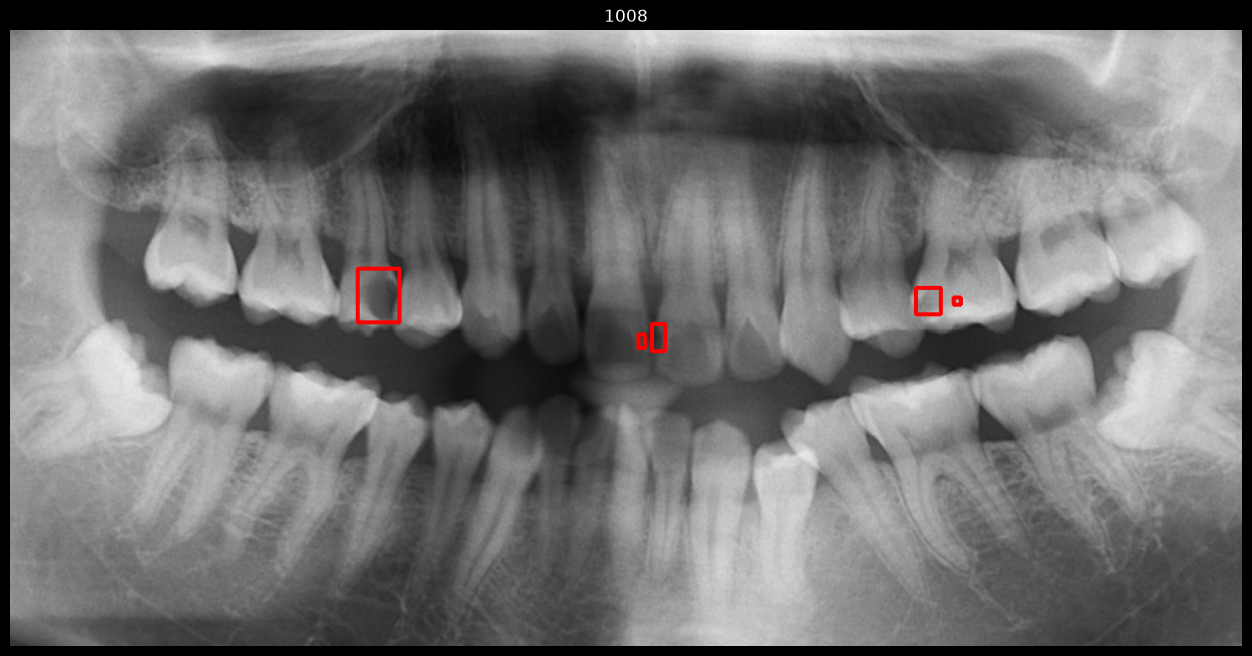

In [5]:
arq = sorted(a for a in os.listdir(lab) if open(os.path.join(lab, a)).read().strip())[0]
stem = arq[:-4]
img = cv2.cvtColor(cv2.imread(f"{img_dir}/{stem}.png"), cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

for linha in open(f"{lab}/{arq}").read().split("\n"):
    if not linha.strip():
        continue
    _, cx, cy, bw, bh = [float(v) for v in linha.split()]
    p1 = (int((cx-bw/2)*w), int((cy-bh/2)*h))
    p2 = (int((cx+bw/2)*w), int((cy+bh/2)*h))
    cv2.rectangle(img, p1, p2, (255, 0, 0), 4)

plt.figure(figsize=(16, 8)); plt.imshow(img); plt.title(stem); plt.axis("off"); plt.show()

In [6]:
pares = []
for img in sorted(os.listdir(dst + "/images")):
    rot = os.path.splitext(img)[0] + ".txt"
    if os.path.exists(dst + "/labels/" + rot):
        pares.append((img, rot))

random.Random(42).shuffle(pares)

n = len(pares)
divisoes = {
    "train": pares[:int(n*0.70)],
    "valid": pares[int(n*0.70):int(n*0.85)],
    "test":  pares[int(n*0.85):],
}

for split, itens in divisoes.items():
    os.makedirs(f"{dst}/{split}/images", exist_ok=True)
    os.makedirs(f"{dst}/{split}/labels", exist_ok=True)
    for img, rot in itens:
        shutil.move(f"{dst}/images/{img}", f"{dst}/{split}/images/{img}")
        shutil.move(f"{dst}/labels/{rot}", f"{dst}/{split}/labels/{rot}")
    print(split, len(itens))

shutil.rmtree(dst + "/images", ignore_errors=True)
shutil.rmtree(dst + "/labels", ignore_errors=True)

train 70
valid 15
test 15


In [17]:
CLASSES = ["carie"]

conteudo = {
    "path": dst,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {i: nome for i, nome in enumerate(CLASSES)},
}

destino = os.path.join(dst, "data.yaml")
with open(destino, "w") as f:
    yaml.dump(conteudo, f, sort_keys=False, allow_unicode=True)

print(open(destino).read())

path: kaggle
train: train/images
val: valid/images
test: test/images
names:
  0: carie



In [18]:
model = YOLO("yolo11s.pt")

model.train(
    data=destino,
    epochs=150,
    imgsz=1024,
    batch=10,
    patience=20,
    seed=42,
)

Ultralytics 8.4.115 🚀 Python-3.14.6 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 7806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=kaggle/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f5ea4fd7620>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [20]:
m = model.val(data=destino, split="test")

print("mAP50:     %.4f" % m.box.map50)
print("mAP50-95:  %.4f" % m.box.map)
print("precisao:  %.4f" % m.box.mp)
print("recall:    %.4f" % m.box.mr)
print("F1:        %.4f" % (2*m.box.mp*m.box.mr / (m.box.mp+m.box.mr)))
print("\nvelocidade (ms/imagem):", {k: round(v,1) for k,v in m.speed.items()})

Ultralytics 8.4.115 🚀 Python-3.14.6 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 7806MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7372.2±1854.7 MB/s, size: 1308.4 KB)
val: Scanning /home/eurico/PyCharmMiscProject/kaggle/test/labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 7.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.5it/s 0.4s
                   all         15         99      0.756      0.333      0.403      0.174
Speed: 1.3ms preprocess, 7.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/eurico/PyCharmMiscProject/runs/detect/val-2
mAP50:     0.4027
mAP50-95:  0.1740
precisao:  0.7555
recall:    0.3333
F1:        0.4626

velocidade (ms/imagem): {'preprocess': 1.3, 'inference': 7.4, 'loss': 0.0, 'postprocess': 0.4}


runs/detect/train

=== results.png


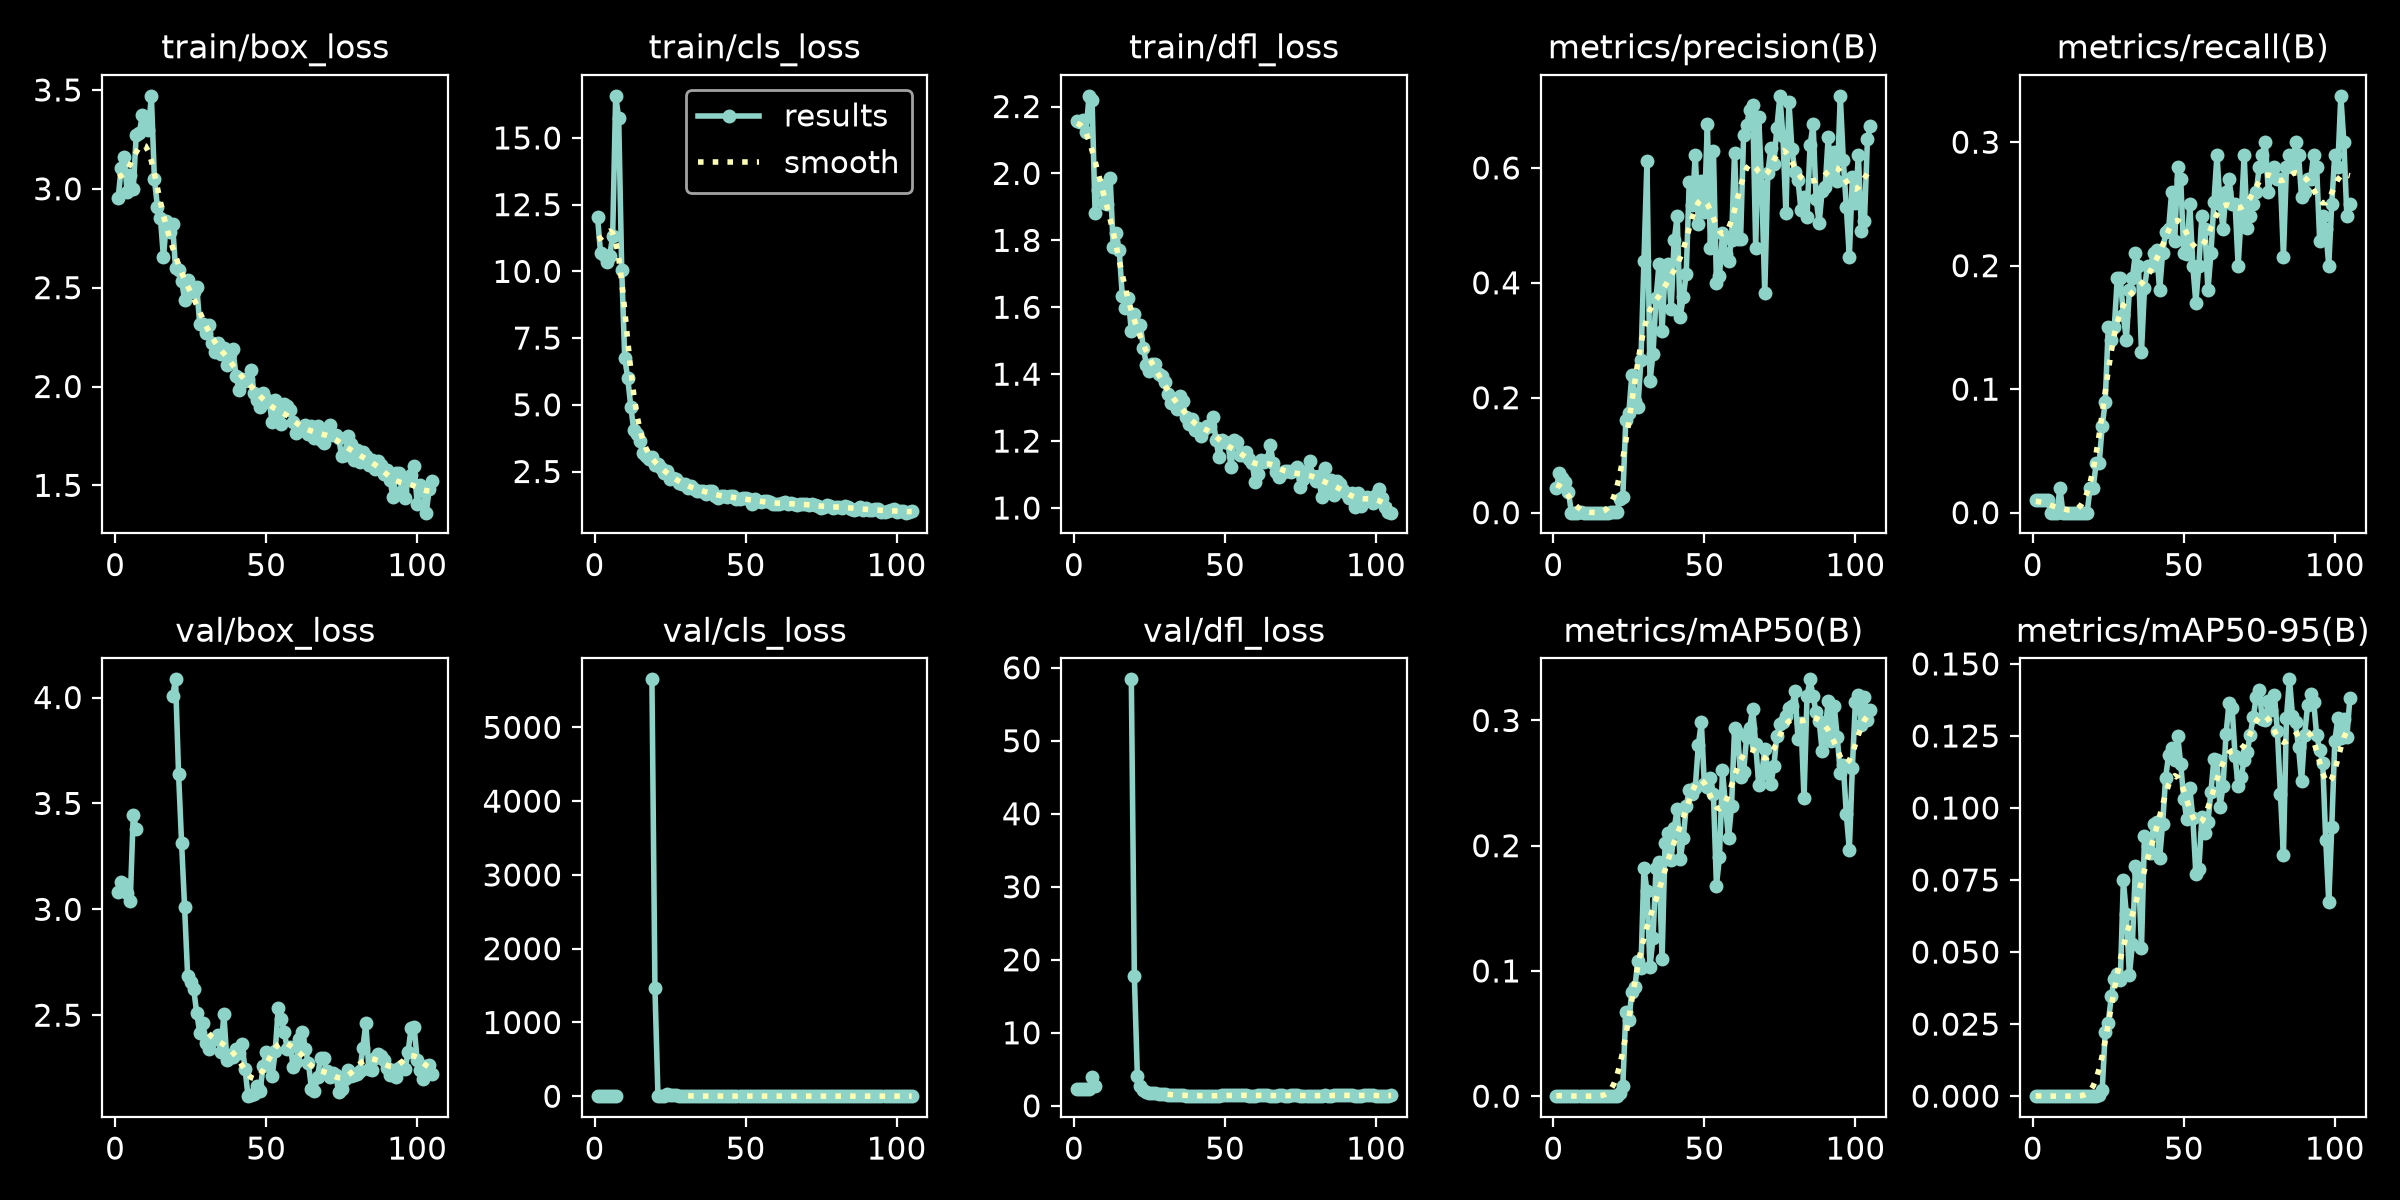


=== confusion_matrix_normalized.png


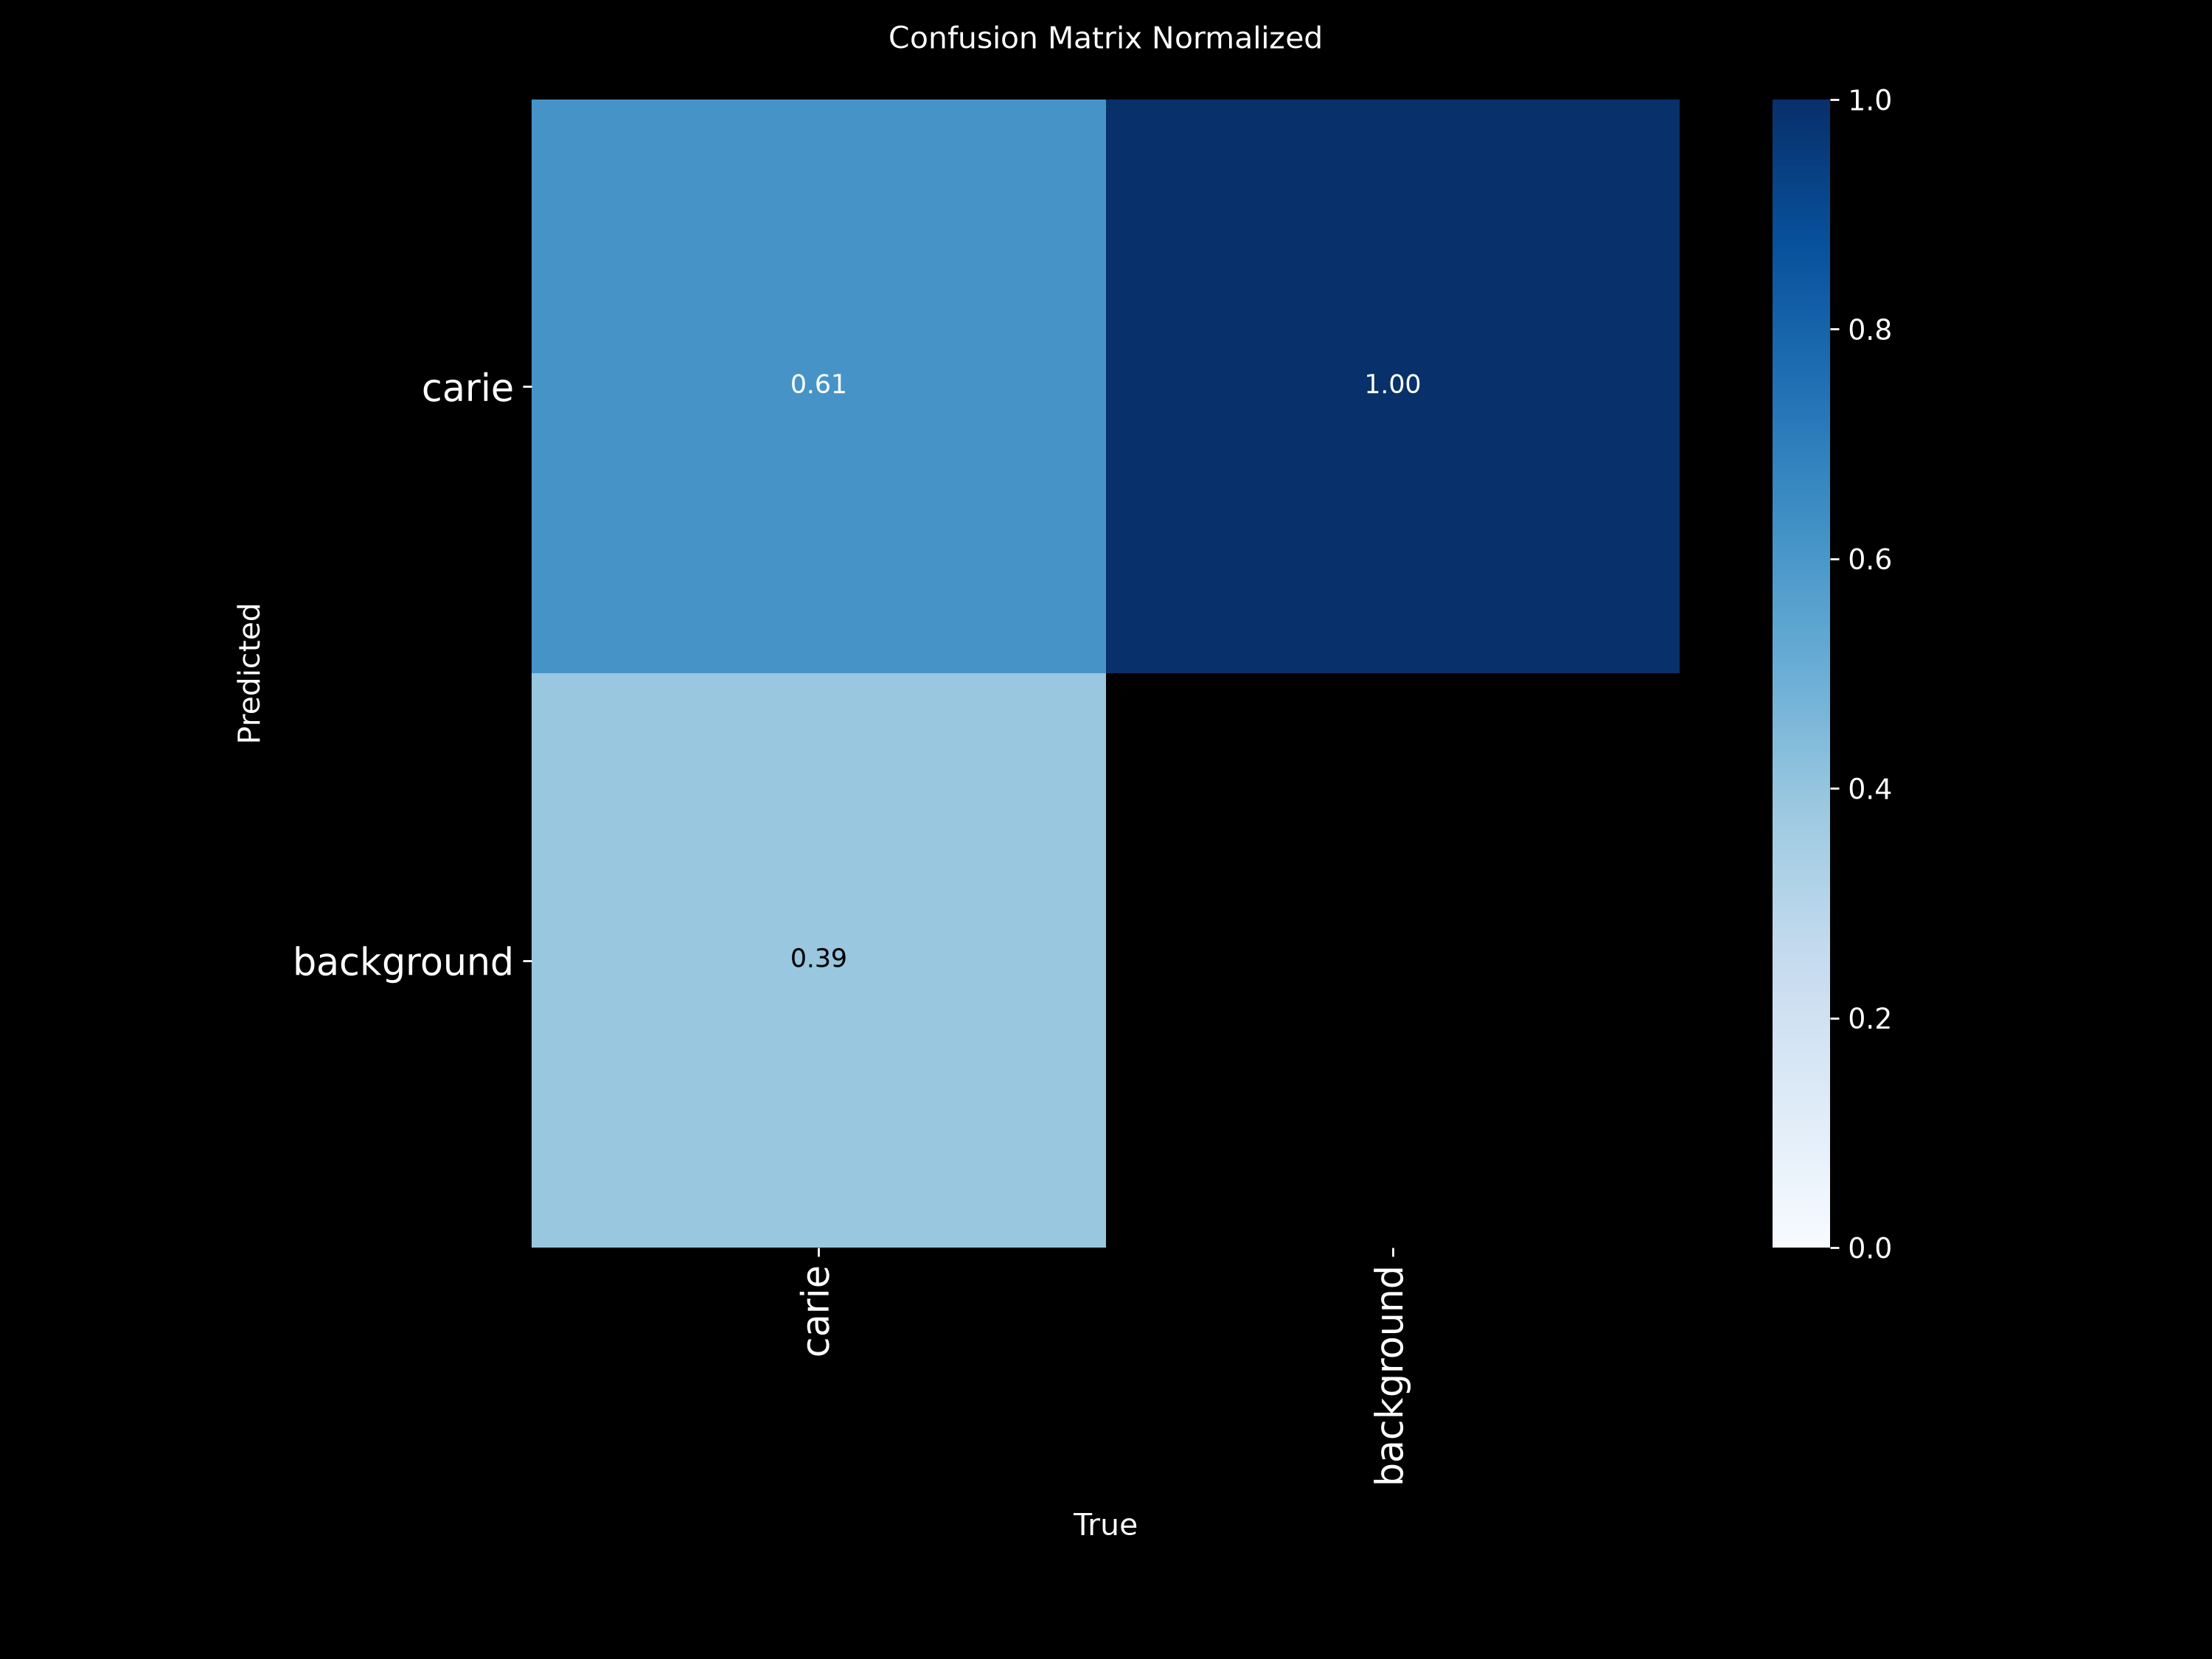


=== labels.jpg


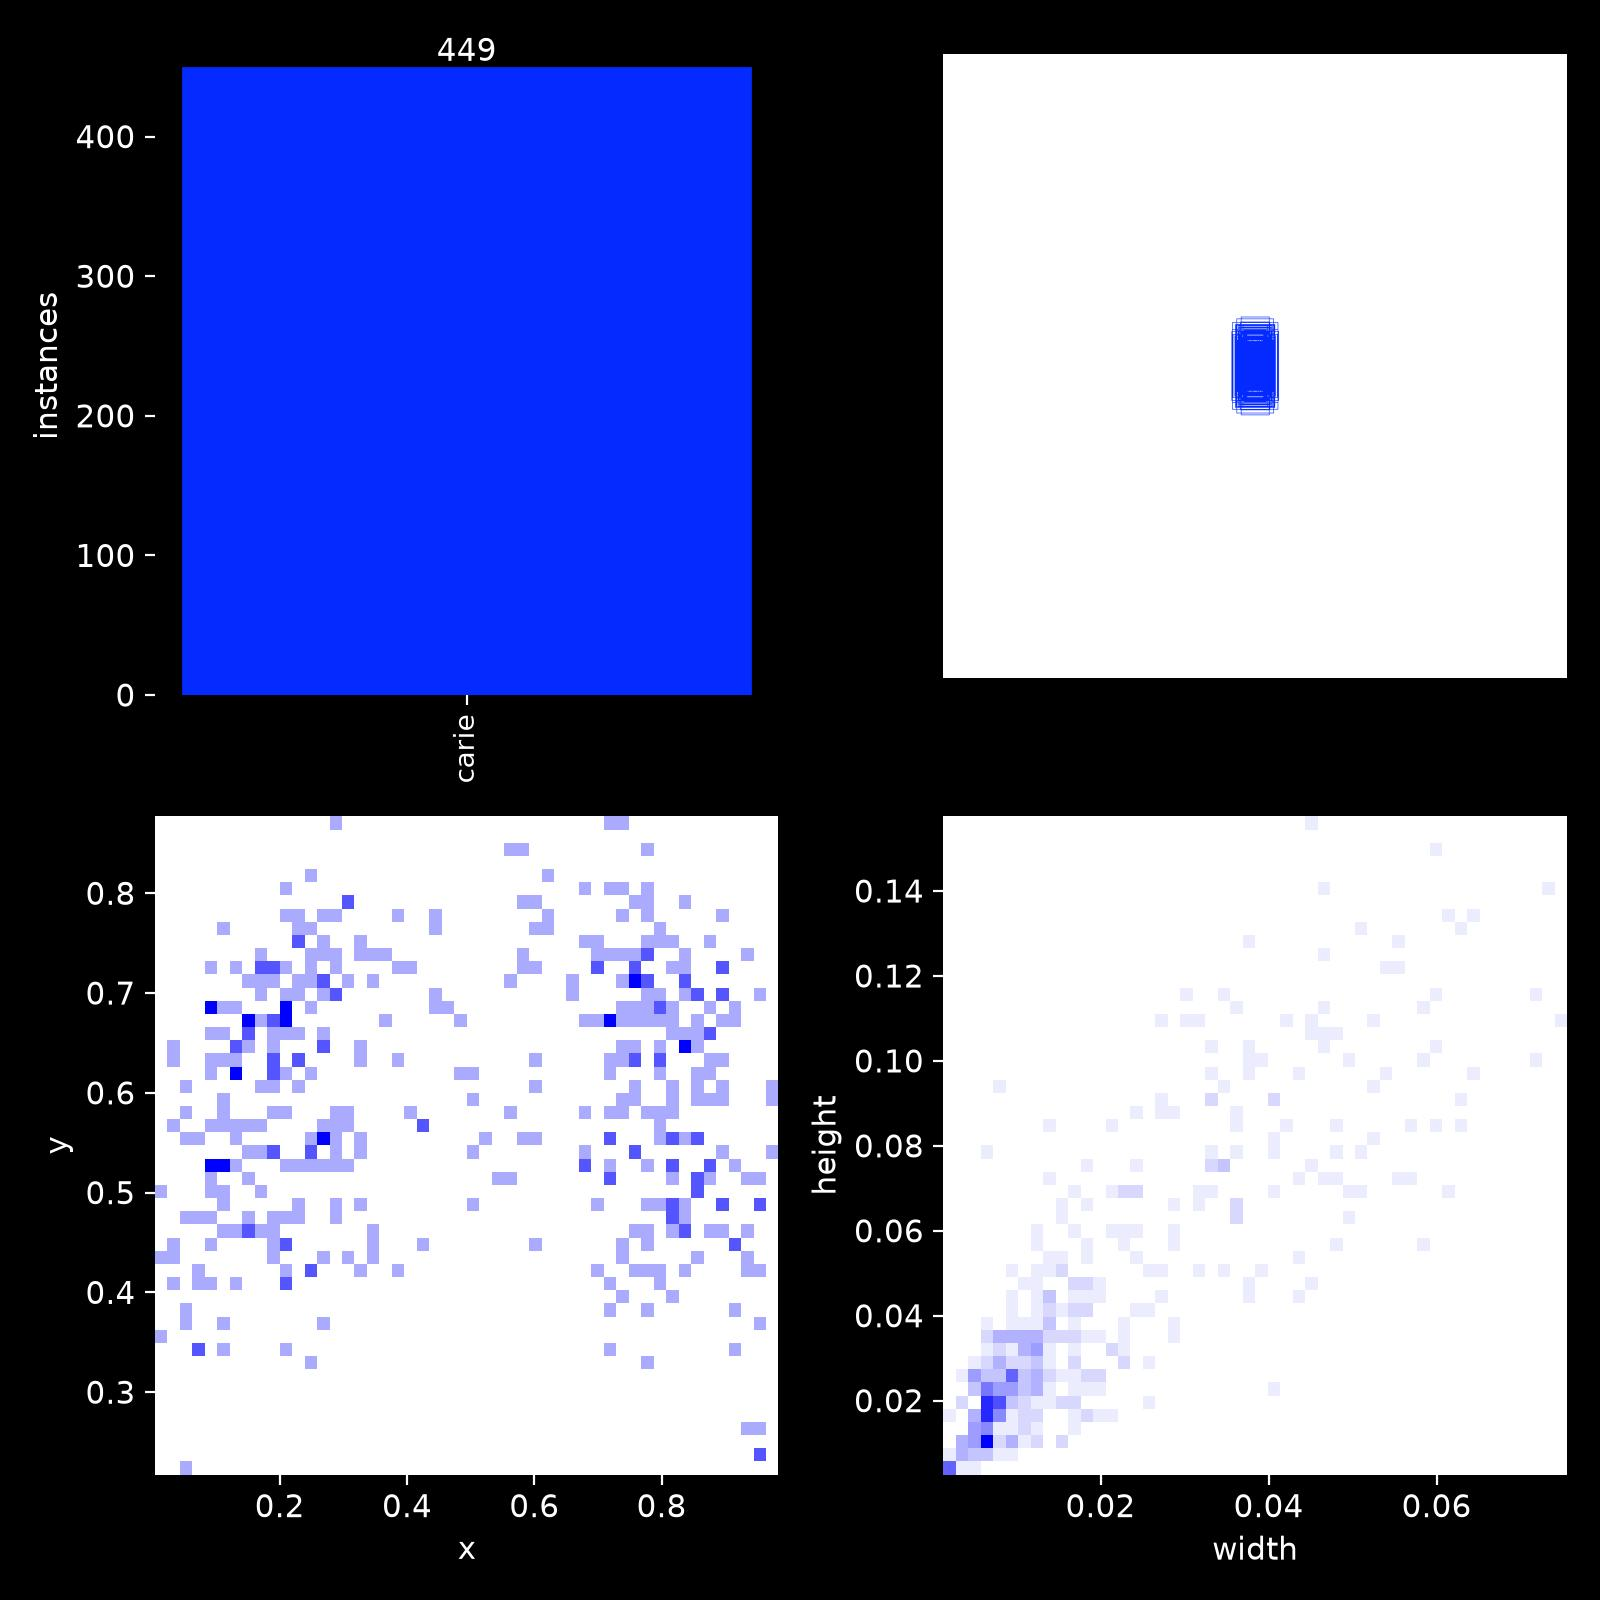


=== val_batch0_labels.jpg


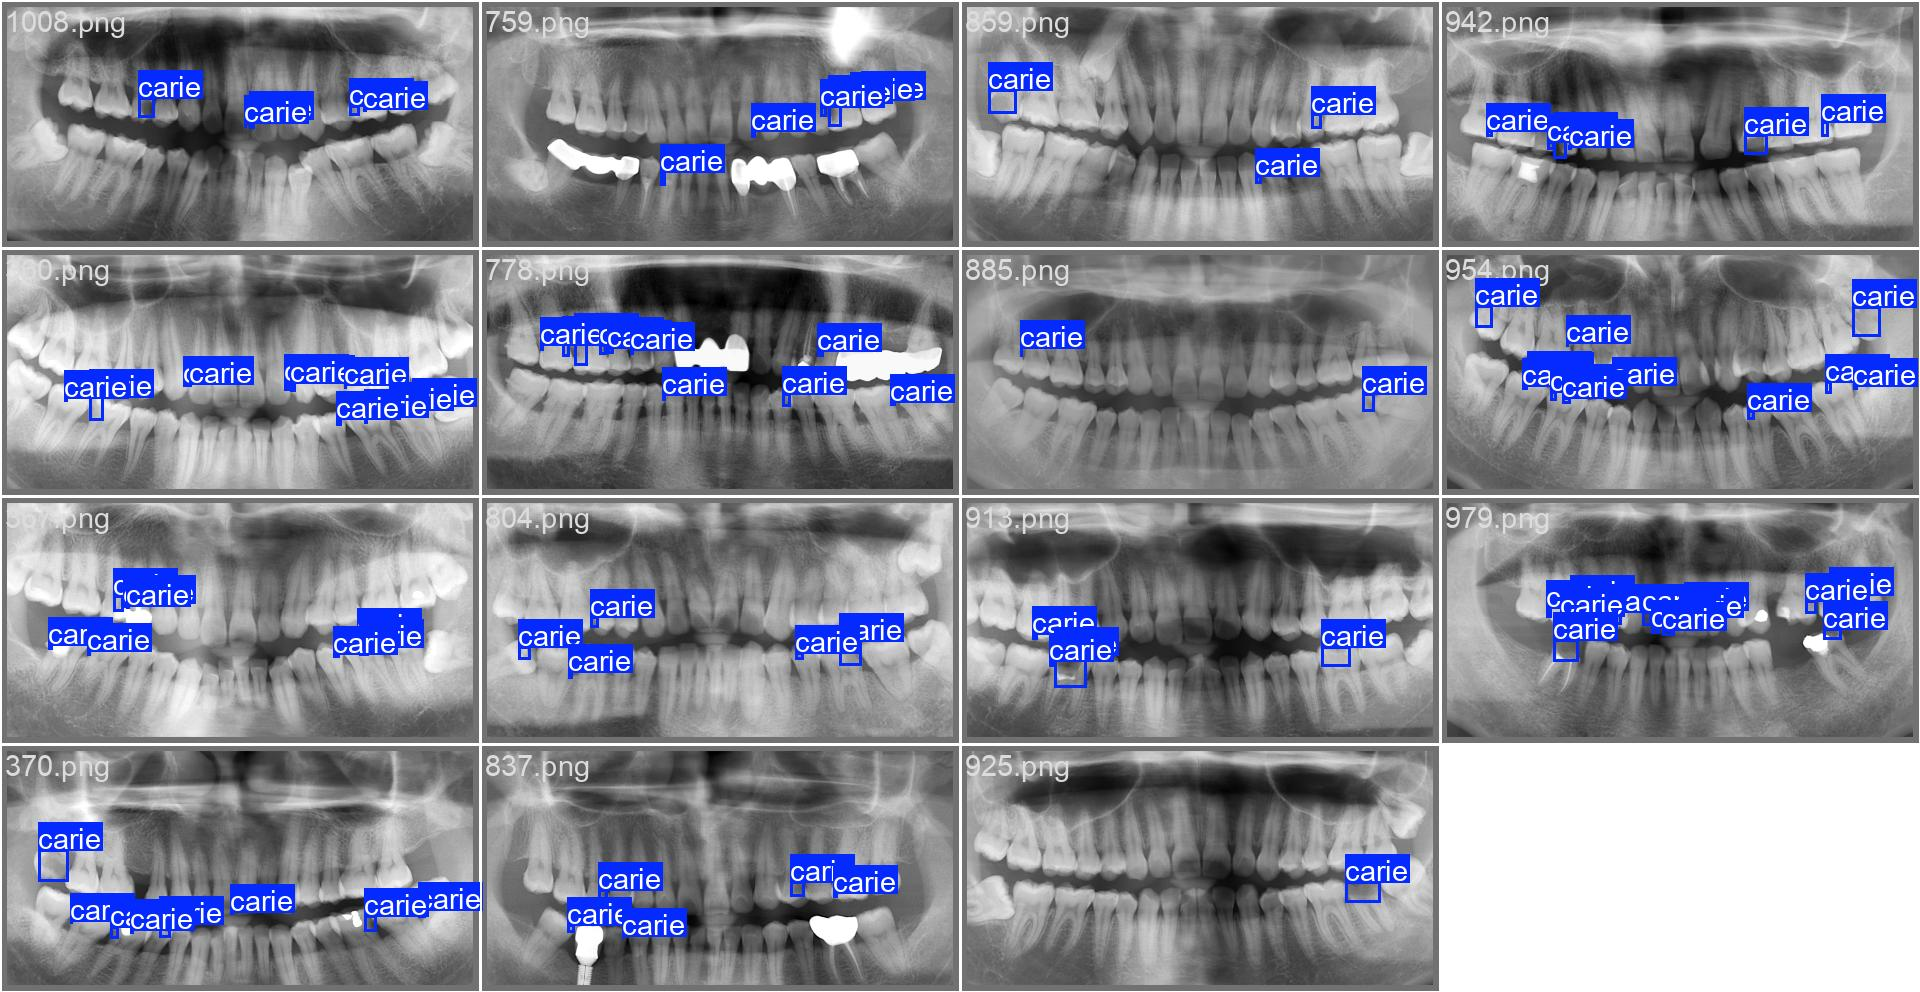


=== val_batch0_pred.jpg


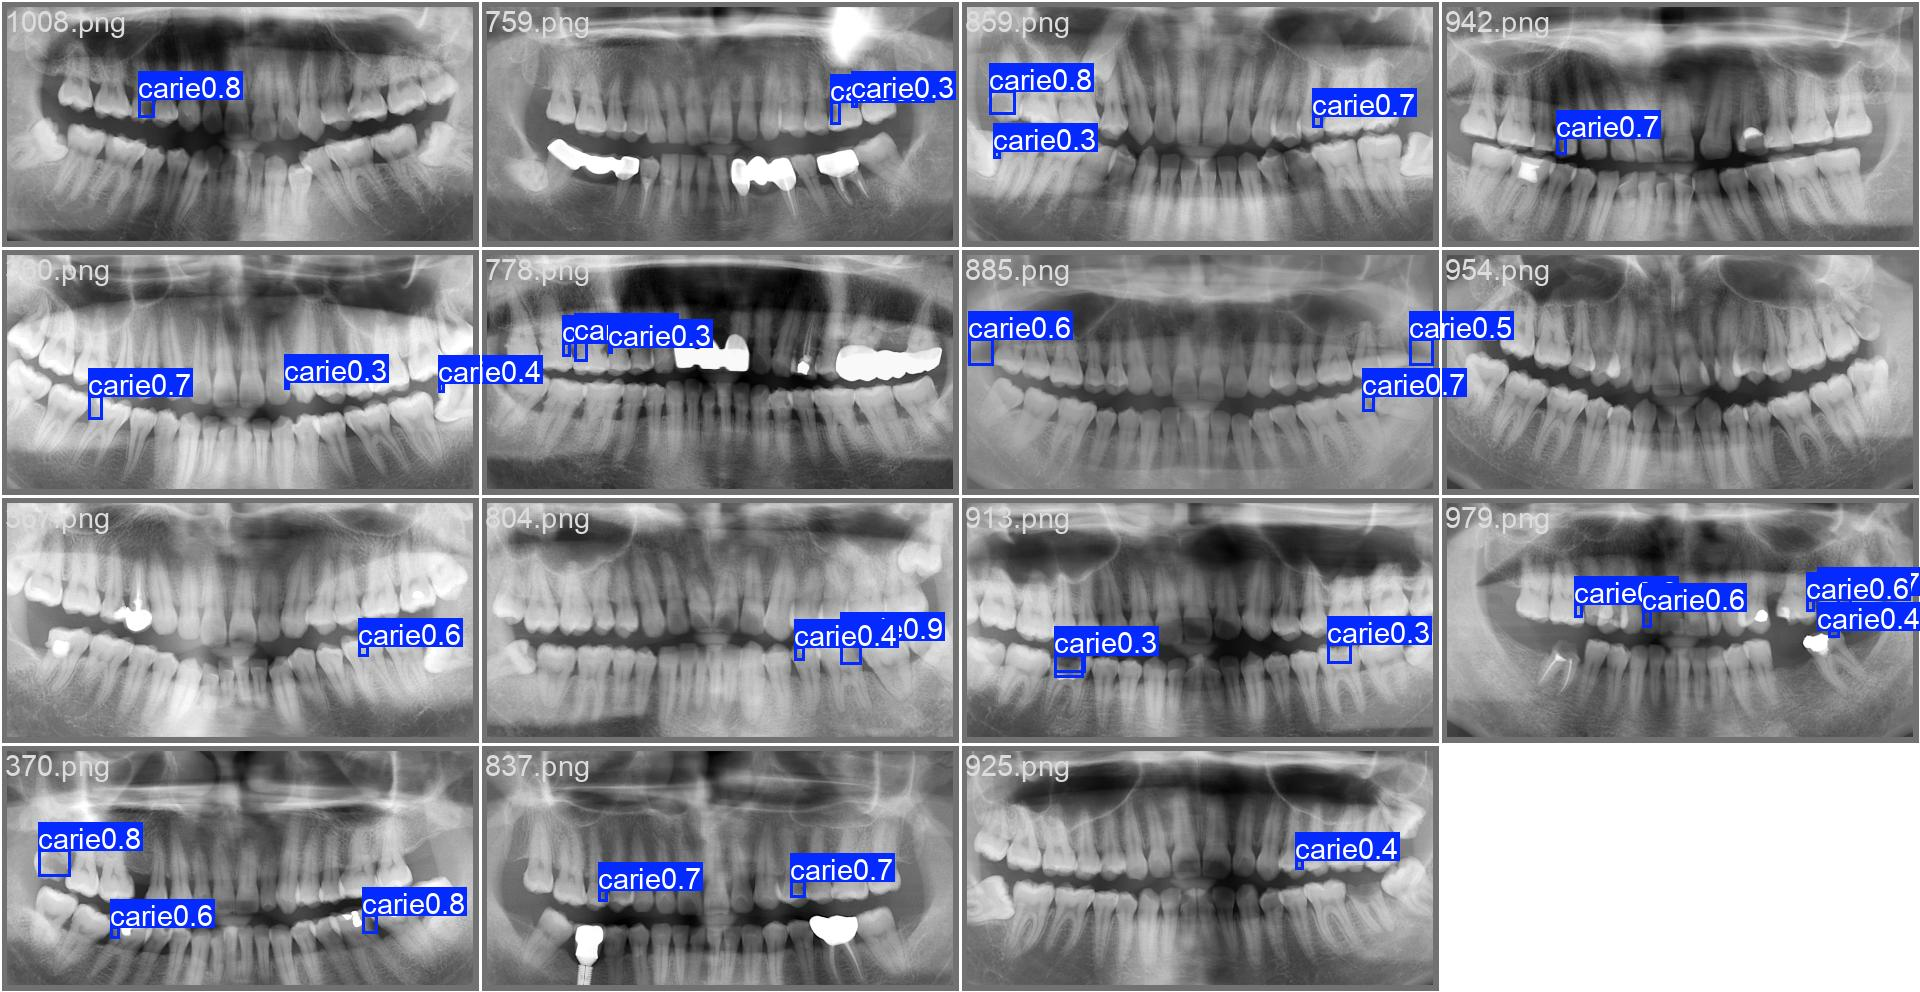

In [22]:
pasta = sorted(glob.glob("runs/detect/train*"))[-1]
print(pasta)

for nome in ["results.png", "PR_curve.png", "F1_curve.png",
             "confusion_matrix_normalized.png", "labels.jpg",
             "val_batch0_labels.jpg", "val_batch0_pred.jpg"]:
    arq = f"{pasta}/{nome}"
    if os.path.exists(arq):
        print("\n===", nome)
        display(Image(filename=arq, width=900))